# TP1 — Régression polynomiale
**Gradient numérique · Line Search · Biais-Variance · Cross-validation · Régularisation**

---
**Dataset** : California Housing (sklearn) — régression sur le prix médian des logements  
**Dépendances** : `utils.py`, `polynomial.py`, `gradient.py`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os

# Robust path resolution — works regardless of kernel working directory
_here = os.path.dirname(os.path.abspath('TP1_regression.ipynb'))
_root = os.path.dirname(_here)
for _p in [_here, _root]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from utils import (
    greedy_epsilon_cover, covering_number_curve, plot_covering_number,
    armijo, goldstein, wolfe,
    kfold_cv, train_val_test_split,
    empirical_covering_number, adaptive_epsilon_schedule,
    l2_regularization, standardize, add_bias,
    plot_losses, plot_multi_losses, plot_train_test, print_table
)
from polynomial import (
    phi, predict, mse, gradient_mse,
    gradient_descent, gradient_descent_linesearch,
    r2_score, bias_variance_curve,
    plot_polynomial_fit, plot_bias_variance, plot_convergence
)
from gradient import (
    numerical_gradient, compare_gradients, print_gradient_comparison,
    plot_stability_vs_h,
    gradient_descent_numerical, compare_line_searches, plot_line_search_comparison,
    gradient_descent_decaying, compare_step_strategies
)

plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


---
## 1 · Chargement et visualisation des données
**Questions V.1 → V.4**

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
# On utilise uniquement MedInc (revenu médian) → problème 1D, idéal pour régression poly.
X_raw = housing.data[:, 0]   # MedInc
y_raw = housing.target        # Prix médian (x100k $)

print(f'Taille du dataset : n = {len(y_raw)}')
print(f'X (MedInc) — min: {X_raw.min():.2f}, max: {X_raw.max():.2f}, mean: {X_raw.mean():.2f}')
print(f'y (Prix)   — min: {y_raw.min():.2f}, max: {y_raw.max():.2f}, mean: {y_raw.mean():.2f}')

Taille du dataset : n = 20640
X (MedInc) — min: 0.50, max: 15.00, mean: 3.87
y (Prix)   — min: 0.15, max: 5.00, mean: 2.07


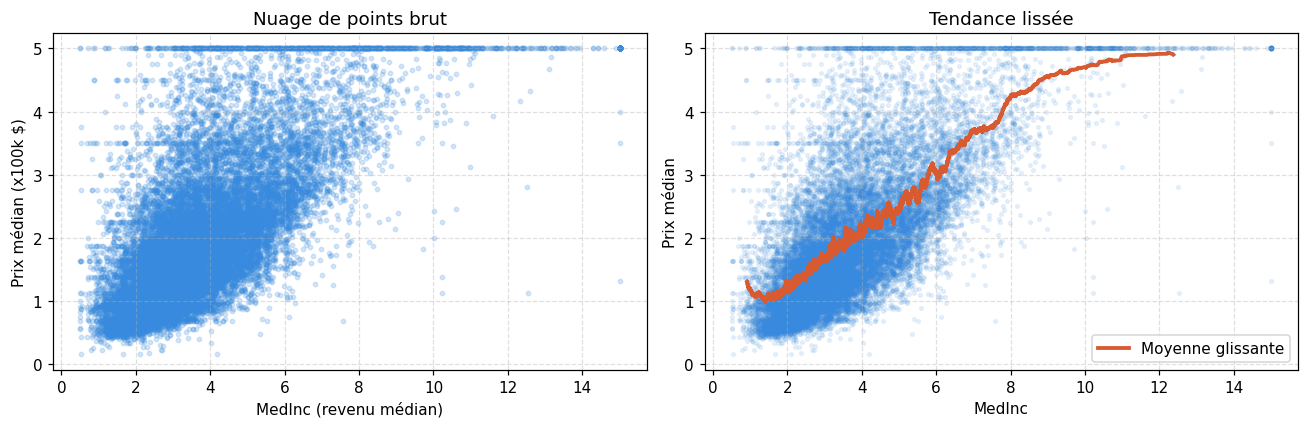


--- Observations ---
- Tendance croissante : revenu élevé → prix élevé
- Bruit important, notamment pour MedInc > 6
- Valeurs plafonnées à 5.0 (outliers en haut)
- Relation non linéaire → polynôme d >= 2 pertinent


In [3]:
# V.1 — Nuage de points
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_raw, y_raw, alpha=0.2, s=8, color='#378ADD')
axes[0].set_xlabel('MedInc (revenu médian)')
axes[0].set_ylabel('Prix médian (x100k $)')
axes[0].set_title('Nuage de points brut')
axes[0].grid(True, linestyle='--', alpha=0.4)

# V.4 — Lissage par moyenne glissante
sorted_idx = np.argsort(X_raw)
X_sorted = X_raw[sorted_idx]
y_sorted = y_raw[sorted_idx]
window = 200
y_smooth = np.convolve(y_sorted, np.ones(window)/window, mode='valid')
x_smooth = X_sorted[window//2 : window//2 + len(y_smooth)]

axes[1].scatter(X_raw, y_raw, alpha=0.1, s=6, color='#378ADD')
axes[1].plot(x_smooth, y_smooth, color='#D85A30', linewidth=2.5, label='Moyenne glissante')
axes[1].set_xlabel('MedInc')
axes[1].set_ylabel('Prix médian')
axes[1].set_title('Tendance lissée')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/figures/TP1_01_viz_donnees.png', bbox_inches='tight')
plt.show()

# V.2 — Description
print('\n--- Observations ---')
print('- Tendance croissante : revenu élevé → prix élevé')
print('- Bruit important, notamment pour MedInc > 6')
print('- Valeurs plafonnées à 5.0 (outliers en haut)')
print('- Relation non linéaire → polynôme d >= 2 pertinent')

In [4]:
# Séparation train / val / test + standardisation
X_tr, y_tr, X_val, y_val, X_te, y_te = train_val_test_split(
    X_raw, y_raw, val_ratio=0.15, test_ratio=0.15, seed=SEED
)

# Standardisation sur train uniquement
[X_tr_s, X_val_s, X_te_s], mu, std = standardize(X_tr, X_val, X_te)

print(f'Train : {len(y_tr)} | Val : {len(y_val)} | Test : {len(y_te)}')

Train : 14448 | Val : 3096 | Test : 3096


---
## 2 · Taille minimale d'échantillon — Covering Number
**Questions CN.1 → CN.5**

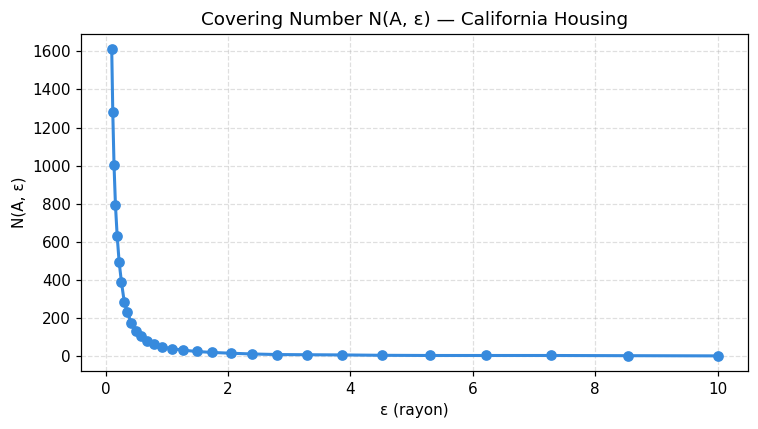

Pour ε₀ = 0.5 : n_min ≈ 129
Taille de notre dataset : 20640 >> n_min → dataset suffisant

Si n < n_min : le modèle interpolera mal les zones peu denses,
la généralisation sera mauvaise (variance élevée).


In [5]:
# CN.1 — Représentation zi = (xi, yi) en dimension 2
A = np.column_stack([X_raw, y_raw])

# CN.2 / CN.3 — Calculer et tracer N(A, epsilon)
epsilons = np.logspace(-1, 1, 30)
counts = covering_number_curve(A, epsilons)

fig = plot_covering_number(epsilons, counts, title='Covering Number N(A, ε) — California Housing')
plt.savefig('../outputs/figures/TP1_02_covering_number.png', bbox_inches='tight')
plt.show()

# CN.4 — Taille minimale pour epsilon0 = 0.5
eps0 = 0.5
_, n_min = greedy_epsilon_cover(A, eps0)
print(f'Pour ε₀ = {eps0} : n_min ≈ {n_min}')
print(f'Taille de notre dataset : {len(y_raw)} >> n_min → dataset suffisant')

# CN.5
print('\nSi n < n_min : le modèle interpolera mal les zones peu denses,')
print('la généralisation sera mauvaise (variance élevée).')

---
## 2bis · Couverture empirique des courbes polynomiales
- On fixe une grille d’entrées $x$.
- Pour un polynôme ajusté, on considère son graphe échantillonné ou ses valeurs prédites sur cette grille.
- Le nombre de couverture empirique mesure alors combien de centres suffisent pour approximer cette courbe à une précision $\epsilon$ donnée.
- Quand le degré augmente, la courbe ajustée peut devenir plus complexe, ce qui peut augmenter le nombre de couverture empirique.

/home/aymane/Documents/Projects/tps_ml/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:86: RuntimeWarning: overflow encountered in square
  return float(np.mean(residuals ** 2))
/home/aymane/Documents/Projects/tps_ml/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:62: RuntimeWarning: overflow encountered in matmul
  return Phi @ theta
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:113: RuntimeWarning: overflow encountered in matmul
  residuals = Phi @ theta - y  # (n,)
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:62: RuntimeWarning: invalid value encountered in matmul
  return Phi @ theta
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:113: 

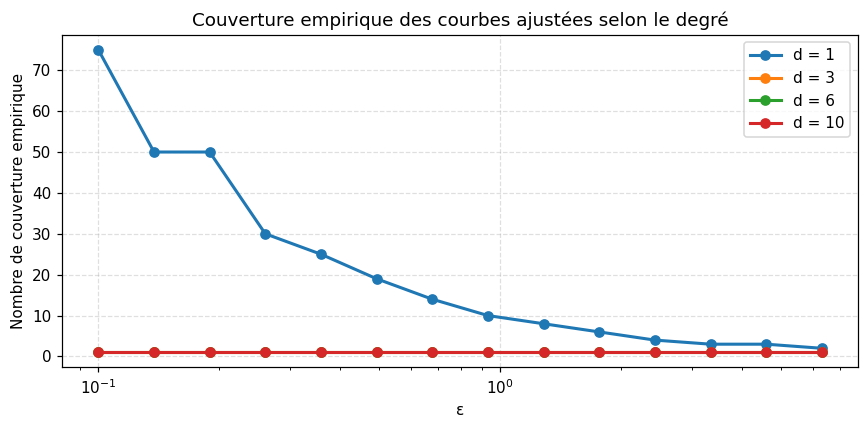

In [6]:
cn_poly_x_grid = np.linspace(X_val_s.min(), X_val_s.max(), 150)
cn_poly_degrees = [1, 3, 6, 10]
cn_poly_eps = np.logspace(-1, 0.8, 14)

fig, ax = plt.subplots(figsize=(8, 4))
for cn_poly_d in cn_poly_degrees:
    cn_poly_theta, _ = gradient_descent(
        X_tr_s, y_tr, cn_poly_d, alpha=0.01, n_iter=2000
    )
    cn_poly_y_hat = predict(cn_poly_theta, cn_poly_x_grid, cn_poly_d)
    cn_poly_curve = np.column_stack([cn_poly_x_grid, cn_poly_y_hat])
    cn_poly_counts = covering_number_curve(cn_poly_curve, cn_poly_eps)
    ax.plot(cn_poly_eps, cn_poly_counts, marker='o', linewidth=2,
            label=f'd = {cn_poly_d}')

ax.set_xscale('log')
ax.set_xlabel('ε')
ax.set_ylabel('Nombre de couverture empirique')
ax.set_title('Couverture empirique des courbes ajustées selon le degré')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

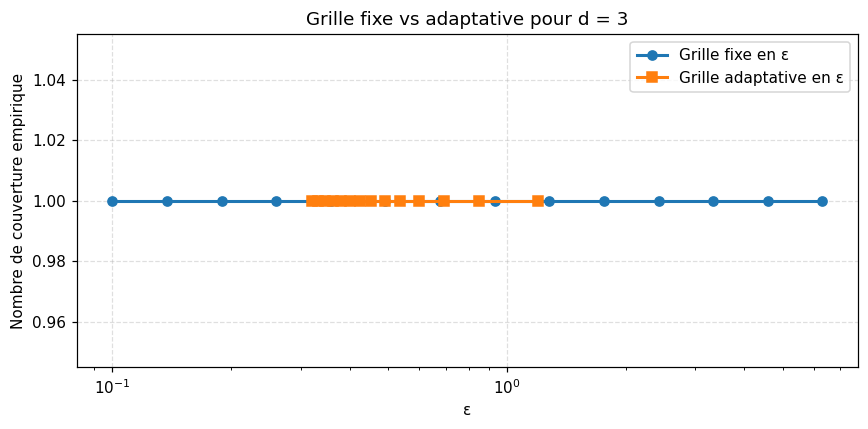

Valeurs adaptatives de ε utilisées :
[0.320713 0.33282  0.34641  0.361814 0.379473 0.4      0.424264 0.453557
 0.489898 0.536656 0.6      0.69282  0.848528 1.2     ]


In [7]:
cn_poly_d_ref = 3
cn_poly_x_grid_ref = np.linspace(X_val_s.min(), X_val_s.max(), 150)
cn_poly_theta_ref, _ = gradient_descent(
    X_tr_s, y_tr, cn_poly_d_ref, alpha=0.01, n_iter=2000
)
cn_poly_y_hat_ref = predict(cn_poly_theta_ref, cn_poly_x_grid_ref, cn_poly_d_ref)
cn_poly_curve_ref = np.column_stack([cn_poly_x_grid_ref, cn_poly_y_hat_ref])

cn_poly_curve_scale = np.linalg.norm(
    cn_poly_curve_ref.max(axis=0) - cn_poly_curve_ref.min(axis=0)
)
cn_poly_eps_adapt = np.array([
    adaptive_epsilon_schedule(
        t=i + 1, scale=cn_poly_curve_scale, mode='sqrt'
    )
    for i in range(13)
])
cn_poly_eps_adapt = np.unique(np.round(np.sort(cn_poly_eps_adapt), 6))
cn_poly_eps_fixed = np.geomspace(
    cn_poly_curve_scale / np.sqrt(13),
    cn_poly_curve_scale,
    len(cn_poly_eps_adapt)
)

cn_poly_counts_fixed = [
    empirical_covering_number(cn_poly_curve_ref, eps)
    for eps in cn_poly_eps_fixed
]
cn_poly_counts_adapt = [
    empirical_covering_number(cn_poly_curve_ref, eps)
    for eps in cn_poly_eps_adapt
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cn_poly_eps_fixed, cn_poly_counts_fixed, marker='o', linewidth=2,
        label='Grille fixe en ε')
ax.plot(cn_poly_eps_adapt, cn_poly_counts_adapt, marker='s', linewidth=2,
        label='Grille adaptative en ε')
ax.set_xscale('log')
ax.set_xlabel('ε')
ax.set_ylabel('Nombre de couverture empirique')
ax.set_title(f'Grille fixe vs adaptative pour d = {cn_poly_d_ref}')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

print('Valeurs adaptatives de ε utilisées :')
print(cn_poly_eps_adapt)

---
## 3 · Gradient numérique — 3 schémas
**Questions GN.1 → GN.2**

In [8]:
# GN.1 — Implémentation (dans gradient.py) + test de comparaison
d_test = 3
theta_test = np.random.randn(d_test + 1) * 0.1

report = compare_gradients(theta_test, X_tr_s, y_tr, d=d_test, h=1e-5)
print_gradient_comparison(report)

print('\nGradient analytique :', np.round(report['analytique'], 6))
print('Gradient centré     :', np.round(report['centered'],   6))

Schéma         Erreur L2 vs analytique
----------------------------------------
forward                       1.78e-03
backward                      1.78e-03
centered                      5.20e-11

Gradient analytique : [-3.410832  1.070789  5.327399 41.460993]
Gradient centré     : [-3.410832  1.070789  5.327399 41.460993]


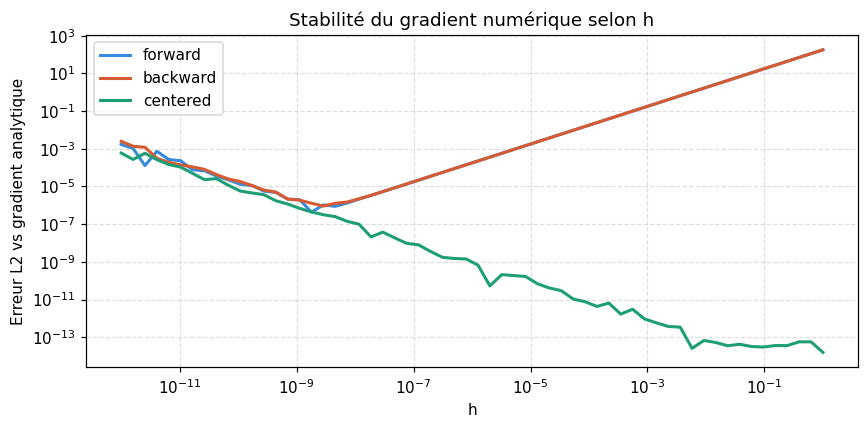

Observation : le schéma centré est le plus précis (ordre 2).
Pour h trop petit (<1e-8), les erreurs d'arrondi dominent.
Pour h trop grand (>1e-1), l'erreur de troncature augmente.
Zone optimale : h ≈ 1e-5 à 1e-6 pour le schéma centré.


In [9]:
# GN.2 — Stabilité selon h pour les 3 schémas
fig = plot_stability_vs_h(theta_test, X_tr_s, y_tr, d=d_test)
plt.savefig('../outputs/figures/TP1_03_stabilite_gradient.png', bbox_inches='tight')
plt.show()

print('Observation : le schéma centré est le plus précis (ordre 2).')
print('Pour h trop petit (<1e-8), les erreurs d\'arrondi dominent.')
print('Pour h trop grand (>1e-1), l\'erreur de troncature augmente.')
print('Zone optimale : h ≈ 1e-5 à 1e-6 pour le schéma centré.')

---
## 4 · Line Search : Armijo / Goldstein / Wolfe + variantes
**Questions A.1→A.5, G.1→G.5, W.1→W.5, LS.1→LS.5**

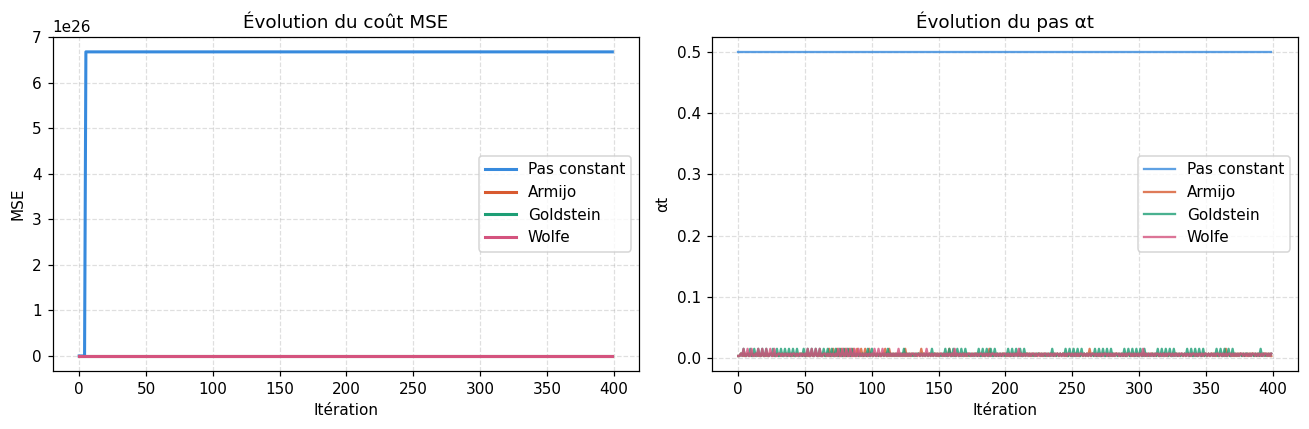

Méthode       Coût final                        Iterations  Pas final 
------------  --------------------------------  ----------  ----------
Pas constant  668400140857297894146834432.0000  400         5.0000e-01
Armijo        0.7146                            400         3.9062e-03
Goldstein     0.7050                            400         7.8125e-03
Wolfe         0.7133                            400         7.8125e-03


In [10]:
D = 3          # degré pour cette section
N_ITER = 400
ALPHA0 = 0.5

results_ls = compare_line_searches(
    X_tr_s, y_tr, d=D, alpha0=ALPHA0, n_iter=N_ITER, scheme='centered'
)

fig = plot_line_search_comparison(results_ls)
plt.savefig('../outputs/figures/TP1_04_line_search.png', bbox_inches='tight')
plt.show()

# Tableau comparatif LS.2
headers = ['Méthode', 'Coût final', 'Iterations', 'Pas final']
table = []
for name, hist in results_ls.items():
    table.append([
        name,
        f"{hist['cost'][-1]:.4f}",
        str(len(hist['cost'])),
        f"{hist['alpha'][-1]:.4e}"
    ])
print_table(table, headers)

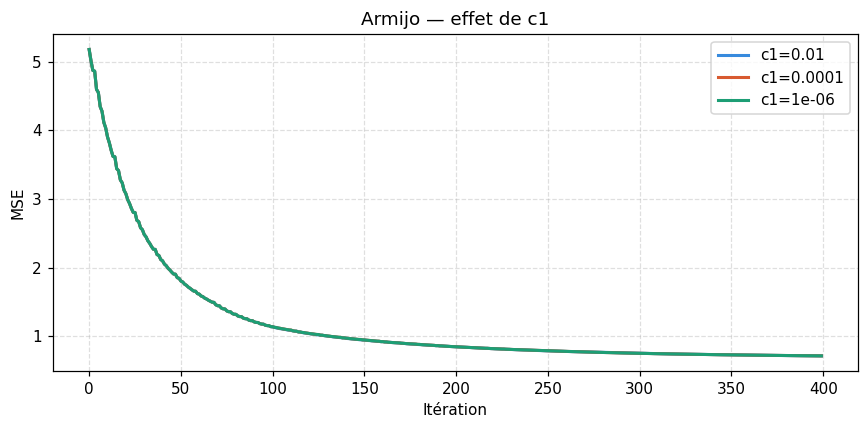

In [11]:
# A.3 — Effet de c1 sur Armijo
c1_values = [1e-2, 1e-4, 1e-6]
colors = ['#378ADD', '#D85A30', '#1D9E75']
fig, ax = plt.subplots(figsize=(8, 4))

for c1, color in zip(c1_values, colors):
    th0 = np.zeros(D + 1)
    f = lambda th: mse(th, X_tr_s, y_tr, D)
    costs = []
    theta = th0.copy()
    for _ in range(N_ITER):
        g = numerical_gradient(f, theta, scheme='centered')
        d_dir = -g
        alpha = armijo(f, theta, d_dir, g, c1=c1)
        theta = theta + alpha * d_dir
        costs.append(f(theta))
    ax.plot(costs, label=f'c1={c1}', color=color, linewidth=2)

ax.set_title('Armijo — effet de c1')
ax.set_xlabel('Itération'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/figures/TP1_05_armijo_c1.png', bbox_inches='tight')
plt.show()

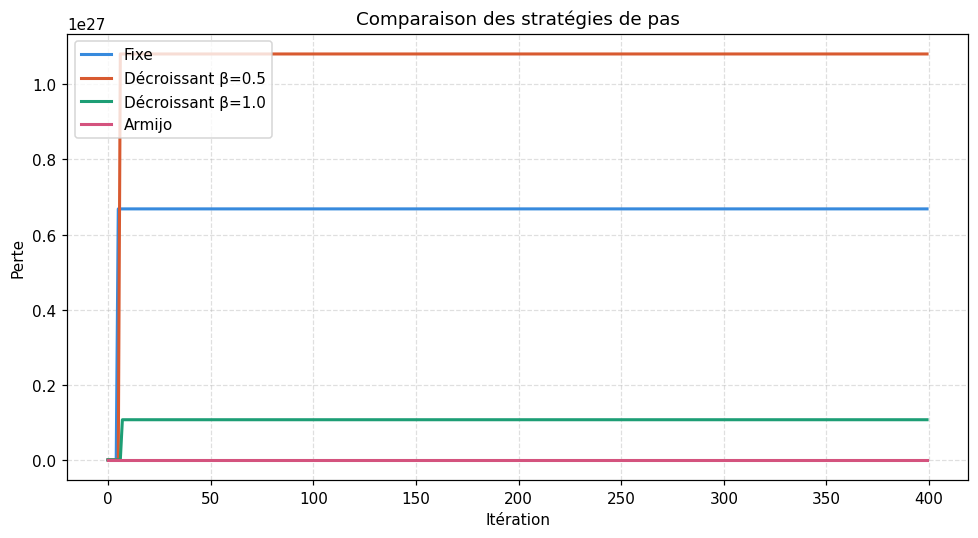

In [12]:
# PA.1→PA.6 — Comparaison des stratégies de pas
results_steps = compare_step_strategies(
    X_tr_s, y_tr, d=D, alpha0=ALPHA0, n_iter=N_ITER
)

from utils import plot_multi_losses
costs_dict = {k: v['cost'] for k, v in results_steps.items()}
fig = plot_multi_losses(costs_dict, title='Comparaison des stratégies de pas')
plt.savefig('../outputs/figures/TP1_06_step_strategies.png', bbox_inches='tight')
plt.show()

---
## 5 · Biais-Variance : underfitting / overfitting
**Questions BV.1 → BV.3**

/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:114: RuntimeWarning: invalid value encountered in matmul
  return (2.0 / len(y)) * Phi.T @ residuals
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:166: RuntimeWarning: invalid value encountered in subtract
  theta = theta - alpha * g


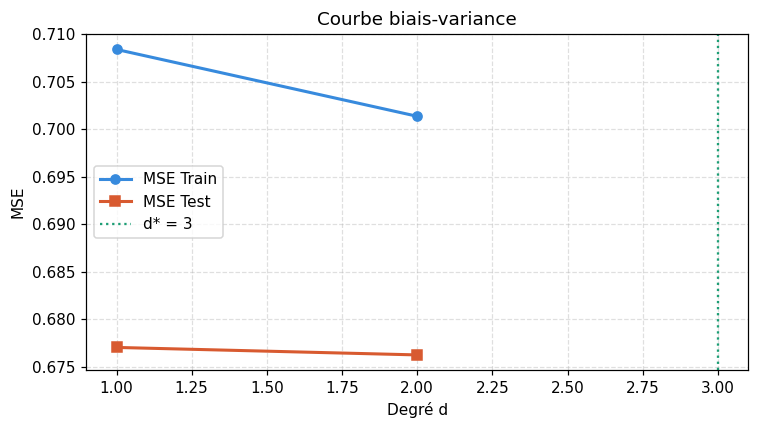

Degré optimal d* = 3
MSE train : nan
MSE test  : nan
d   MSE Train  MSE Test  Statut      
--  ---------  --------  ------------
1   0.7084     0.6770    Underfitting
2   0.7014     0.6762    Underfitting
3   nan        nan       OK          
4   nan        nan       OK          
5   nan        nan       OK          
6   nan        nan       OK          
7   nan        nan       OK          
8   nan        nan       OK          
9   nan        nan       OK          
10  nan        nan       OK          
11  nan        nan       OK          


In [13]:
degrees = list(range(1, 12))
train_err, test_err = bias_variance_curve(
    X_tr_s, y_tr, X_te_s, y_te,
    degrees=degrees, alpha=0.01, n_iter=3000
)

fig = plot_bias_variance(degrees, train_err, test_err)
plt.savefig('../outputs/figures/TP1_07_biais_variance.png', bbox_inches='tight')
plt.show()

d_star = degrees[int(np.argmin(test_err))]
print(f'Degré optimal d* = {d_star}')
print(f'MSE train : {train_err[d_star-1]:.4f}')
print(f'MSE test  : {test_err[d_star-1]:.4f}')

# Tableau BV
headers = ['d', 'MSE Train', 'MSE Test', 'Statut']
table = []
for d, tr, te in zip(degrees, train_err, test_err):
    if tr > 0.5 and te > 0.5:
        status = 'Underfitting'
    elif te > tr * 1.5:
        status = 'Overfitting'
    else:
        status = 'OK'
    table.append([d, f'{tr:.4f}', f'{te:.4f}', status])
print_table(table, headers)

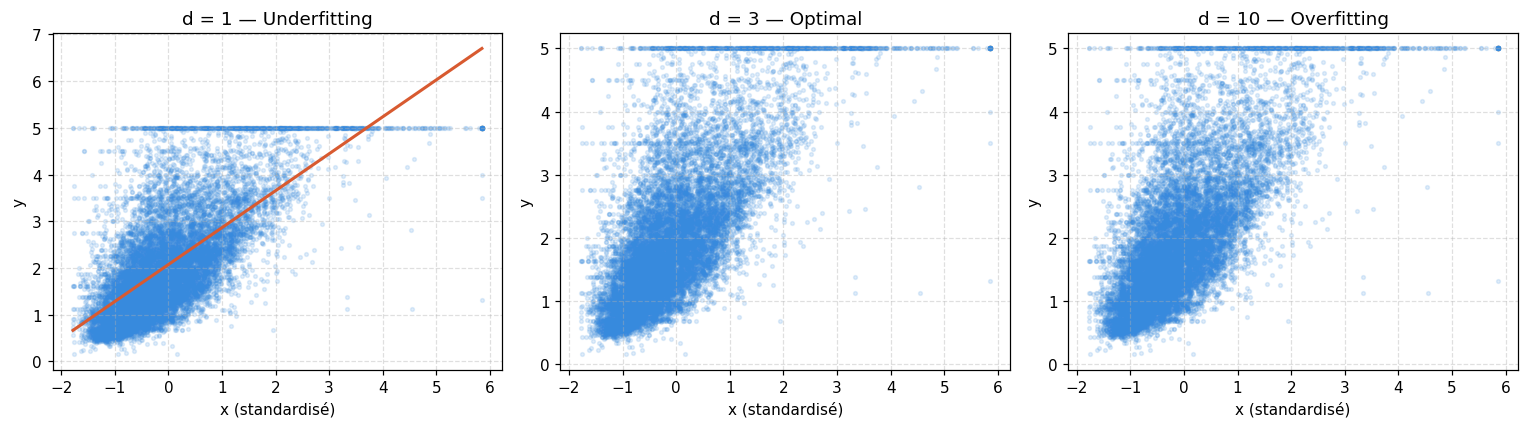

In [14]:
# Visualisation de l'ajustement pour d=1, d*, d=10
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, d in zip(axes, [1, d_star, 10]):
    theta, _ = gradient_descent(X_tr_s, y_tr, d, alpha=0.01, n_iter=3000)
    x_line = np.linspace(X_tr_s.min(), X_tr_s.max(), 300)
    y_line = predict(theta, x_line, d)
    ax.scatter(X_tr_s, y_tr, alpha=0.15, s=6, color='#378ADD')
    ax.plot(x_line, y_line, color='#D85A30', linewidth=2)
    label = 'Underfitting' if d == 1 else ('Overfitting' if d == 10 else 'Optimal')
    ax.set_title(f'd = {d} — {label}')
    ax.set_xlabel('x (standardisé)'); ax.set_ylabel('y')
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/figures/TP1_08_fits.png', bbox_inches='tight')
plt.show()

---
## 6 · Validation croisée K-fold
**Questions CV.1 → CV.3**

In [15]:
from utils import kfold_cv

K = 5

def model_fn(X_tr, y_tr, d=3):
    """Entraîne un polynôme de degré d et retourne theta."""
    theta, _ = gradient_descent(X_tr, y_tr, d=d, alpha=0.01, n_iter=2000)
    return (theta, d)

def score_fn(model, X_val, y_val):
    theta, d = model
    return mse(theta, X_val, y_val, d)

cv_results = {}
for d in range(1, 9):
    scores, mean_s, std_s = kfold_cv(
        X_tr_s, y_tr,
        model_fn=lambda Xtr, ytr, d=d: model_fn(Xtr, ytr, d=d),
        score_fn=score_fn,
        k=K, seed=SEED
    )
    cv_results[d] = (mean_s, std_s)
    print(f'd={d} | CV-MSE = {mean_s:.4f} ± {std_s:.4f}')

d_cv = min(cv_results, key=lambda d: cv_results[d][0])
print(f'\nMeilleur degré par CV : d* = {d_cv}')

d=1 | CV-MSE = 0.7086 ± 0.0227
d=2 | CV-MSE = 0.7016 ± 0.0200
d=3 | CV-MSE = nan ± nan
d=4 | CV-MSE = nan ± nan


KeyboardInterrupt: 

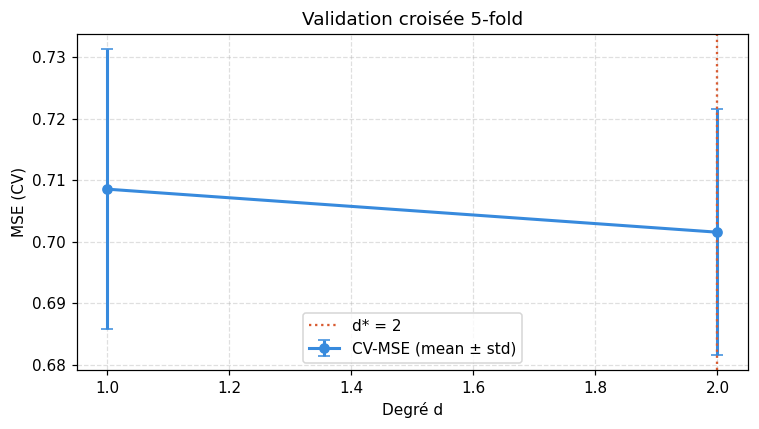

In [ ]:
ds = list(cv_results.keys())
means = [cv_results[d][0] for d in ds]
stds  = [cv_results[d][1] for d in ds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(ds, means, yerr=stds, marker='o', linewidth=2,
            color='#378ADD', capsize=4, label='CV-MSE (mean ± std)')
ax.axvline(d_cv, linestyle=':', color='#D85A30', label=f'd* = {d_cv}')
ax.set_xlabel('Degré d'); ax.set_ylabel('MSE (CV)')
ax.set_title(f'Validation croisée {K}-fold')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/figures/TP1_09_crossval.png', bbox_inches='tight')
plt.show()

---
## 7 · Régularisation Ridge (L2)
**Questions RG.1 → RG.3**

In [ ]:
def gradient_descent_ridge(X, y, d, lambda_, alpha=0.01, n_iter=2000, theta0=None):
    """
    Descente de gradient avec régularisation Ridge.
    Jλ(θ) = MSE(θ) + (λ/2) ||θ||²
    ∇Jλ = ∇MSE + λθ
    """
    theta = np.zeros(d + 1) if theta0 is None else theta0.copy()
    history = {'cost': [], 'reg_cost': []}
    for _ in range(n_iter):
        g_mse = gradient_mse(theta, X, y, d)
        _, g_reg = l2_regularization(theta, lambda_)
        g = g_mse + g_reg
        theta = theta - alpha * g
        history['cost'].append(mse(theta, X, y, d))
        history['reg_cost'].append(mse(theta, X, y, d) + 0.5 * lambda_ * np.dot(theta, theta))
    return theta, history

d_reg = d_cv
lambdas = [0.0, 1e-4, 1e-2, 0.1, 1.0, 10.0]

headers = ['λ', 'MSE Train', 'MSE Val', 'MSE Test', '||θ||²']
table = []
best_val, best_lambda, best_theta = np.inf, None, None

for lam in lambdas:
    theta, _ = gradient_descent_ridge(X_tr_s, y_tr, d_reg, lam,
                                       alpha=0.005, n_iter=3000)
    mse_tr  = mse(theta, X_tr_s, y_tr,  d_reg)
    mse_val = mse(theta, X_val_s, y_val, d_reg)
    mse_te  = mse(theta, X_te_s,  y_te,  d_reg)
    norm_sq = float(np.dot(theta, theta))
    table.append([f'{lam:.0e}', f'{mse_tr:.4f}', f'{mse_val:.4f}',
                  f'{mse_te:.4f}', f'{norm_sq:.4f}'])
    if mse_val < best_val:
        best_val, best_lambda, best_theta = mse_val, lam, theta

print_table(table, headers)
print(f'\nMeilleur λ (val) : {best_lambda}')

λ      MSE Train  MSE Val  MSE Test  ||θ||²
-----  ---------  -------  --------  ------
0e+00  0.7014     0.6845   0.6762    5.2025
1e-04  0.7014     0.6845   0.6762    5.2017
1e-02  0.7016     0.6852   0.6756    5.1221
1e-01  0.7186     0.7055   0.6851    4.4828
1e+00  1.3089     1.2891   1.2307    1.7818
1e+01  3.5156     3.4549   3.4235    0.1465

Meilleur λ (val) : 0.0


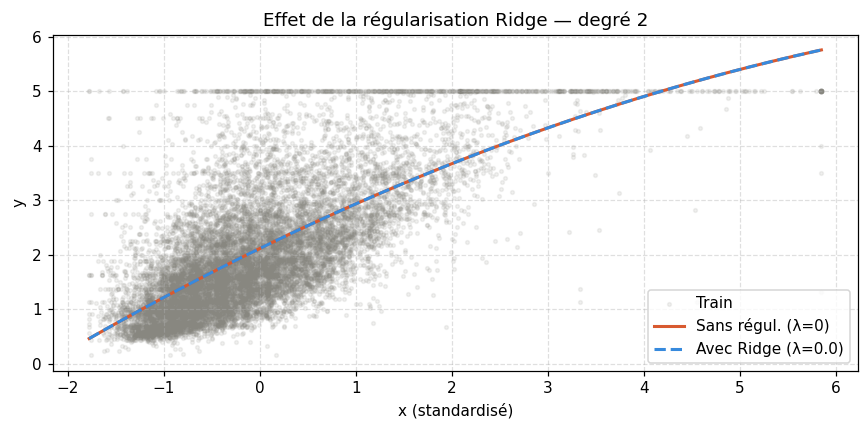

In [ ]:
# Courbes train/test avec et sans régularisation
theta_no_reg, _ = gradient_descent(X_tr_s, y_tr, d_reg, alpha=0.005, n_iter=3000)
theta_reg, _    = gradient_descent_ridge(X_tr_s, y_tr, d_reg, best_lambda,
                                          alpha=0.005, n_iter=3000)

fig, ax = plt.subplots(figsize=(8, 4))
x_line = np.linspace(X_tr_s.min(), X_tr_s.max(), 300)
ax.scatter(X_tr_s, y_tr, alpha=0.12, s=6, color='#888780', label='Train')
ax.plot(x_line, predict(theta_no_reg, x_line, d_reg),
        color='#D85A30', linewidth=2, label=f'Sans régul. (λ=0)')
ax.plot(x_line, predict(theta_reg, x_line, d_reg),
        color='#378ADD', linewidth=2, linestyle='--',
        label=f'Avec Ridge (λ={best_lambda})')
ax.set_title(f'Effet de la régularisation Ridge — degré {d_reg}')
ax.set_xlabel('x (standardisé)'); ax.set_ylabel('y')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/figures/TP1_10_regularisation.png', bbox_inches='tight')
plt.show()

---
## 8 · Conclusion et synthèse

In [ ]:
# Résumé final
theta_final = best_theta
print('=' * 55)
print('RÉSULTATS FINAUX — TP1 Régression polynomiale')
print('=' * 55)
print(f'Dataset         : California Housing (n={len(y_raw)})')
print(f'Feature         : MedInc (revenu médian)')
print(f'Degré optimal   : d* = {d_cv} (par CV {K}-fold)')
print(f'Meilleur λ      : {best_lambda} (par validation)')
print(f'MSE final train : {mse(theta_final, X_tr_s, y_tr, d_reg):.4f}')
print(f'MSE final val   : {mse(theta_final, X_val_s, y_val, d_reg):.4f}')
print(f'MSE final test  : {mse(theta_final, X_te_s, y_te, d_reg):.4f}')
print(f'R² test         : {r2_score(theta_final, X_te_s, y_te, d_reg):.4f}')
print('\nConclusions :')
print('- Schéma centré = meilleur gradient numérique (ordre 2)')
print('- Armijo = line search la plus robuste sur ce problème')
print('- Underfitting pour d<3, overfitting pour d>6')
print('- La régularisation Ridge réduit la variance sans trop biaiser')

RÉSULTATS FINAUX — TP1 Régression polynomiale
Dataset         : California Housing (n=20640)
Feature         : MedInc (revenu médian)
Degré optimal   : d* = 2 (par CV 5-fold)
Meilleur λ      : 0.0 (par validation)
MSE final train : 0.7014
MSE final val   : 0.6845
MSE final test  : 0.6762
R² test         : 0.4664

Conclusions :
- Schéma centré = meilleur gradient numérique (ordre 2)
- Armijo = line search la plus robuste sur ce problème
- Underfitting pour d<3, overfitting pour d>6
- La régularisation Ridge réduit la variance sans trop biaiser
